# Flow matching from a Gaussian to three Dirac masses

This notebook studies the stochastic interpolant
\[
X_t = a(t)X_0+b(t)X_1,\qquad t\in[0,1],
\]
with \(X_0\sim\mathcal N(0,I_2)\) and \(X_1\), independently of \(X_0\),
uniformly supported on three Dirac masses \(y_1,y_2,y_3\).  The goal is to
visualize the probability-flow velocity
\[
u_t(x)=\mathbb E[\dot a(t)X_0+\dot b(t)X_1\mid X_t=x],
\]
then compare its trajectories with the semi-discrete optimal-transport rays.

## Closed-form density and conditional velocity

Conditionally on \(X_1=y_k\), the random variable \(X_t\) is Gaussian:
\[
X_t\mid X_1=y_k \sim \mathcal N(b(t)y_k,a(t)^2I_2).
\]
For mixture weights \(\pi_k\), the density is therefore
\[
p_t(x)=\sum_{k=1}^3 \pi_k\,\varphi_{a(t)^2I_2}(x-b(t)y_k).
\]
Bayes' formula gives the posterior responsibility
\[
\gamma_k(x,t)=
\frac{\pi_k\exp\left(-\frac{\|x-b(t)y_k\|^2}{2a(t)^2}\right)}
{\sum_{\ell=1}^3\pi_\ell\exp\left(-\frac{\|x-b(t)y_\ell\|^2}{2a(t)^2}\right)}.
\]
Since \(X_0=(X_t-b(t)X_1)/a(t)\) whenever \(a(t)>0\),
\[
u_t(x)=\frac{\dot a(t)}{a(t)}x+
\left(\dot b(t)-\frac{\dot a(t)b(t)}{a(t)}\right)
\sum_{k=1}^3\gamma_k(x,t)y_k .
\]
All evaluations below use PyTorch tensors, including the posterior weights and
Runge-Kutta integration of the ODE \(\dot x_t=u_t(x_t)\).

In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "python":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "python"))

FIG_DIR = PROJECT_ROOT / "paper" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import torch

from stochastic_interpolants import (
    DTYPE,
    SCHEDULES,
    dirac_points,
    integrate_trajectories,
    log_density,
    nearest_labels,
    ot_trajectories,
    path_lengths,
    velocity,
)

torch.set_default_dtype(DTYPE)
torch.manual_seed(7)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "legend.frameon": False,
})

palette = np.array(["#3666a6", "#d17c2f", "#4b9a62"])
points = dirac_points()
points_np = points.numpy()
points

tensor([[ 2.4000,  0.0000],
        [-1.2000,  2.0785],
        [-1.2000, -2.0785]])

## The three interpolation schedules

We compare three common choices satisfying the same endpoint constraints:
\[
\begin{array}{c|cc}
\text{schedule} & a(t) & b(t)\\
\hline
\text{linear} & 1-t & t\\
\text{variance preserving} & \sqrt{1-t} & \sqrt t\\
\text{cosine} & \cos(\pi t/2) & \sin(\pi t/2).
\end{array}
\]
They induce the same terminal law, but not the same time-dependent velocity
field or sample trajectories.  The square-root schedule has singular endpoint
derivatives, so the numerical ODE is evaluated on
\([10^{-4},1-10^{-4}]\).

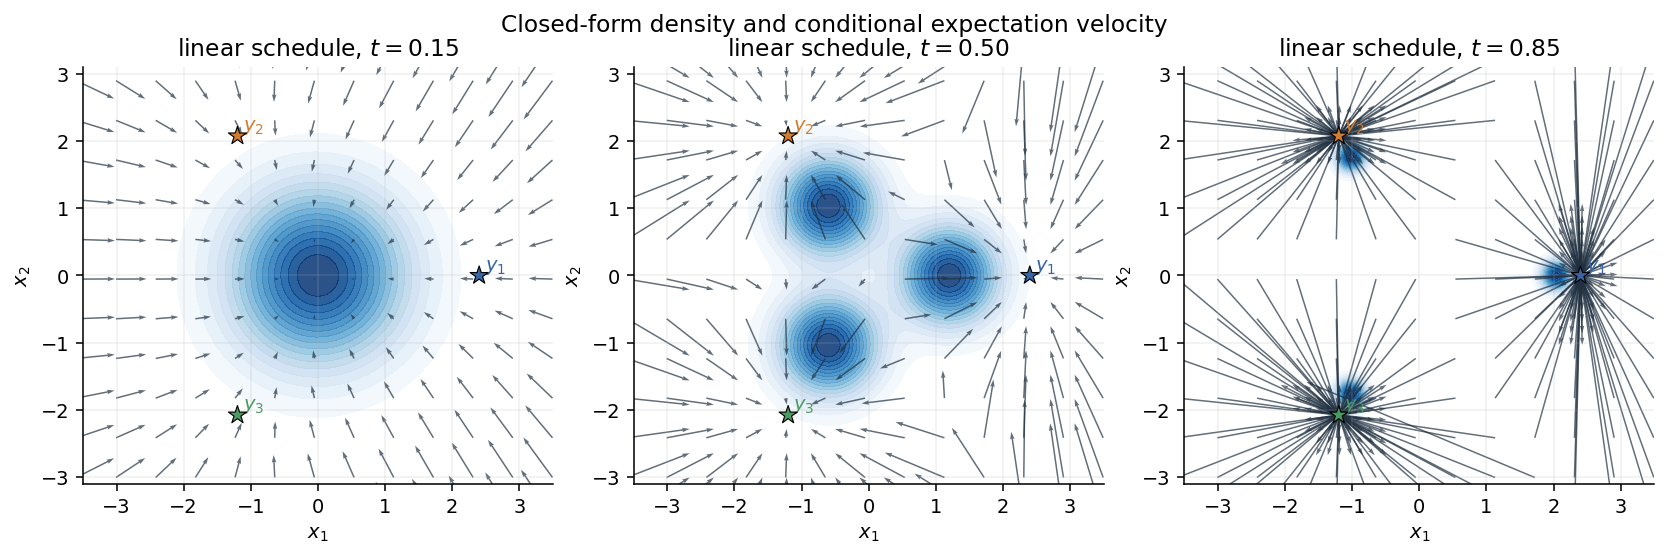

In [2]:
def draw_targets(ax):
    ax.scatter(points_np[:, 0], points_np[:, 1], s=95, c=palette, marker="*", edgecolor="black", linewidth=0.6, zorder=5)
    for k, y in enumerate(points_np):
        ax.text(y[0] + 0.08, y[1] + 0.08, f"$y_{k+1}$", color=palette[k], weight="bold")


def set_equal_panel(ax, title=None):
    ax.set_aspect("equal")
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.1, 3.1)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    if title:
        ax.set_title(title)


grid_1d = torch.linspace(-3.6, 3.6, 135)
xx, yy = torch.meshgrid(grid_1d, grid_1d, indexing="xy")
flat = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.65), constrained_layout=True)
for ax, t in zip(axes, [0.15, 0.50, 0.85]):
    dens = torch.exp(log_density(flat, t, points, "linear")).reshape(xx.shape).numpy()
    levels = np.linspace(0.0, dens.max(), 18)[1:]
    ax.contourf(xx.numpy(), yy.numpy(), dens, levels=levels, cmap="Blues", alpha=0.86)
    stride = 11
    sample = torch.stack([xx[::stride, ::stride].reshape(-1), yy[::stride, ::stride].reshape(-1)], dim=1)
    vel = velocity(sample, t, points, "linear").numpy()
    ax.quiver(
        sample[:, 0].numpy(),
        sample[:, 1].numpy(),
        vel[:, 0],
        vel[:, 1],
        color="#203040",
        alpha=0.70,
        width=0.0032,
        scale=36,
    )
    draw_targets(ax)
    set_equal_panel(ax, rf"linear schedule, $t={t:.2f}$")

fig.suptitle("Closed-form density and conditional expectation velocity", y=1.04)
fig.savefig(FIG_DIR / "dirac_density_velocity.pdf", bbox_inches="tight")
plt.show()

The contours above are not kernel estimates. They are the exact Gaussian
mixture density \(p_t\), and the arrows are the conditional expectation
velocity evaluated by PyTorch from the posterior weights \(\gamma_k(x,t)\).

In [3]:
n_samples = 150
x0 = torch.randn(n_samples, 2, dtype=DTYPE)

paths = {}
stats = []
for info in SCHEDULES:
    ts, path = integrate_trajectories(x0, points, info.key, n_steps=520)
    labels = nearest_labels(path[-1], points)
    lengths = path_lengths(path)
    endpoint_error = torch.linalg.norm(path[-1] - points[labels], dim=1)
    paths[info.key] = (ts, path, labels, lengths, endpoint_error)
    stats.append((info.label, lengths.mean().item(), lengths.std().item(), endpoint_error.mean().item()))

print("schedule                  mean arc length   std arc length   mean endpoint error")
for row in stats:
    print(f"{row[0]:26s} {row[1]:15.4f} {row[2]:16.4f} {row[3]:20.4e}")

schedule                  mean arc length   std arc length   mean endpoint error
linear                              1.7644           0.4223           2.4422e-04
variance preserving                 1.8395           0.3614           9.4729e-03
cosine                              1.8300           0.3580           2.0427e-04


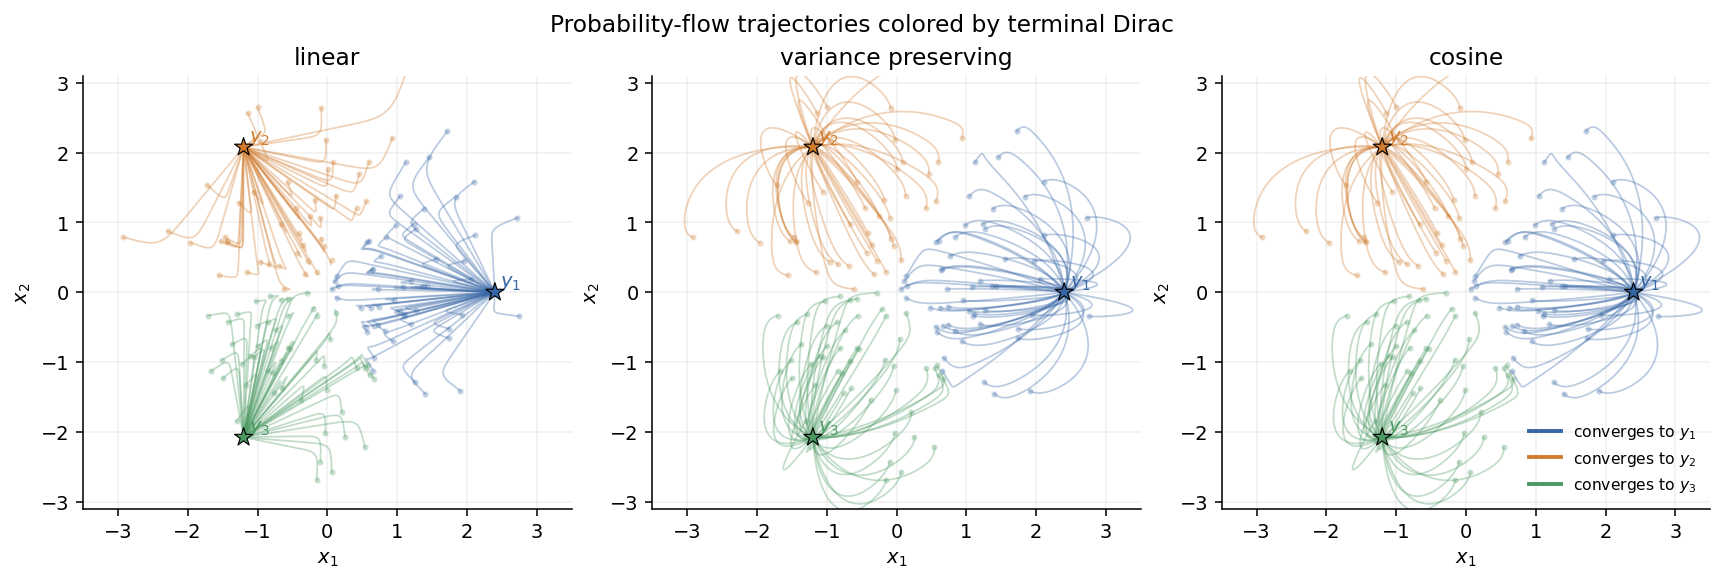

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.85), constrained_layout=True)
for ax, info in zip(axes, SCHEDULES):
    _, path, labels, _, _ = paths[info.key]
    path_np = path.numpy()
    labels_np = labels.numpy()
    for i in range(n_samples):
        col = palette[labels_np[i]]
        ax.plot(path_np[:, i, 0], path_np[:, i, 1], color=col, alpha=0.34, linewidth=0.9)
        ax.scatter(path_np[0, i, 0], path_np[0, i, 1], color=col, s=5, alpha=0.22)
    draw_targets(ax)
    set_equal_panel(ax, info.label)

legend_handles = [
    Line2D([0], [0], color=palette[k], lw=2, label=rf"converges to $y_{k+1}$")
    for k in range(3)
]
axes[-1].legend(handles=legend_handles, loc="lower right", fontsize=8)
fig.suptitle("Probability-flow trajectories colored by terminal Dirac", y=1.04)
fig.savefig(FIG_DIR / "dirac_schedule_comparison.pdf", bbox_inches="tight")
plt.show()

Although the endpoint law is identical, the schedules bend time differently.
The linear schedule rapidly contracts noise while translating toward the
posterior mean. The square-root and cosine schedules keep more variance at
intermediate times, producing visibly different curvature before the terminal
collapse.

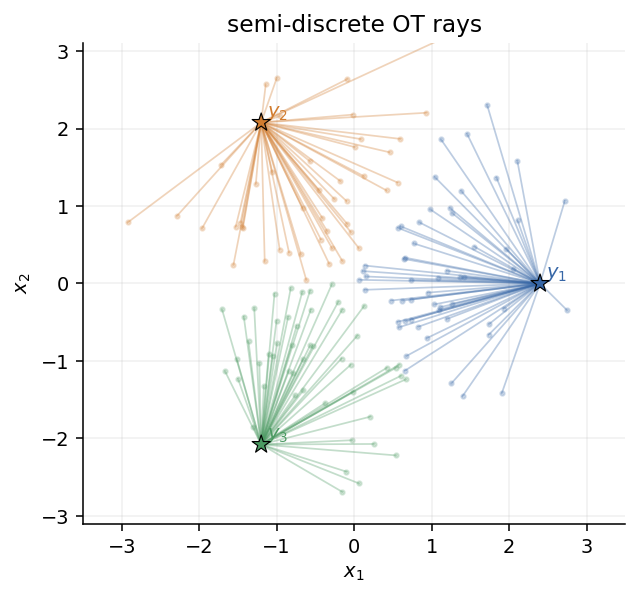

OT mean arc length: 1.5257


In [5]:
ts_ot, path_ot, labels_ot = ot_trajectories(x0, points, n_steps=220)
length_ot = path_lengths(path_ot)

fig, ax = plt.subplots(figsize=(4.7, 4.15), constrained_layout=True)
path_ot_np = path_ot.numpy()
labels_ot_np = labels_ot.numpy()
for i in range(n_samples):
    col = palette[labels_ot_np[i]]
    ax.plot(path_ot_np[:, i, 0], path_ot_np[:, i, 1], color=col, alpha=0.33, linewidth=0.9)
    ax.scatter(path_ot_np[0, i, 0], path_ot_np[0, i, 1], color=col, s=5, alpha=0.22)
draw_targets(ax)
set_equal_panel(ax, "semi-discrete OT rays")
fig.savefig(FIG_DIR / "dirac_ot_trajectories.pdf", bbox_inches="tight")
plt.show()

print(f"OT mean arc length: {length_ot.mean().item():.4f}")

For this equilateral, equal-weight target, the semi-discrete OT Laguerre cells
have equal dual weights by rotational symmetry.  Because the three targets have
the same norm, these Laguerre cells reduce to the nearest-vertex cones.  OT
therefore sends each source point to its nearest Dirac mass and interpolates
along a straight segment.  The stochastic-interpolant probability flow is
different: it is a deterministic flow with the same marginal endpoints, but it
is not constrained to be the Brenier transport map at \(t=1\).

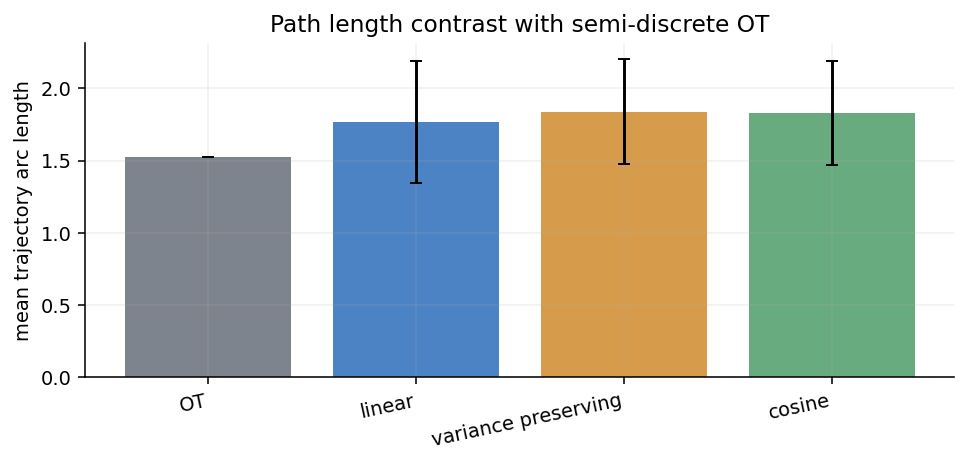

In [6]:
names = ["OT"] + [info.label for info in SCHEDULES]
means = [length_ot.mean().item()] + [paths[info.key][3].mean().item() for info in SCHEDULES]
errs = [0.0] + [paths[info.key][3].std().item() for info in SCHEDULES]

fig, ax = plt.subplots(figsize=(6.8, 3.2), constrained_layout=True)
bar_colors = ["#69707a"] + [info.color for info in SCHEDULES]
ax.bar(np.arange(len(names)), means, yerr=errs, color=bar_colors, alpha=0.86, capsize=3)
ax.set_xticks(np.arange(len(names)), names, rotation=12, ha="right")
ax.set_ylabel("mean trajectory arc length")
ax.set_title("Path length contrast with semi-discrete OT")
fig.savefig(FIG_DIR / "dirac_path_length_comparison.pdf", bbox_inches="tight")
plt.show()